In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

print("kernel working")

kernel working


In [3]:
tc14_rates = pd.read_csv("houston_amsterdam_clean_38k_rates.csv")
tc14_rates.head()
tc14_rates.columns



Index(['date', 'worldscale_rate', 'usd_per_bbl'], dtype='str')

2024-07-12    5.298817
2024-07-19    5.298817
2024-07-26    5.298817
2024-08-02    5.298817
2024-08-09    5.298817
                ...   
2026-06-05    5.298817
2026-06-12    5.298817
2026-06-19    5.298817
2026-06-26    5.298817
2026-07-03    5.298817
Freq: W-FRI, Length: 104, dtype: float64


c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


<Axes: xlabel='date'>

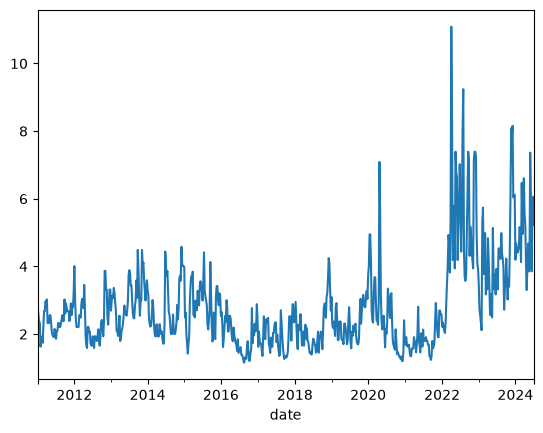

In [4]:
#make sure data is in the right format for train test split 

# index is already date, just ensure it's datetime
tc14_rates["date"] = pd.to_datetime(
    tc14_rates["date"],
    format="%d/%m/%y"
)

tc14_rates = tc14_rates.sort_values("date")
tc14_rates = tc14_rates.set_index("date")

series = tc14_rates["usd_per_bbl"]

train = series[:-104]
test = series[-104:]

tc14_model = ExponentialSmoothing(train, trend = None, seasonal = None, seasonal_periods = 52)



fit_tc14= tc14_model.fit()
pred_tc14 = fit_tc14.forecast(len(test))
print(pred_tc14)

train.plot()

In [5]:
print(tc14_rates.index)
print(tc14_rates.index.freq)
print(tc14_rates.head())

DatetimeIndex(['2011-01-07', '2011-01-14', '2011-01-21', '2011-01-28',
               '2011-02-04', '2011-02-11', '2011-02-18', '2011-02-25',
               '2011-03-04', '2011-03-11',
               ...
               '2026-05-01', '2026-05-08', '2026-05-15', '2026-05-22',
               '2026-05-29', '2026-06-05', '2026-06-12', '2026-06-19',
               '2026-06-26', '2026-07-03'],
              dtype='datetime64[us]', name='date', length=809, freq=None)
None
            worldscale_rate  usd_per_bbl
date                                    
2011-01-07            120.0      2.79150
2011-01-14            110.0      2.55888
2011-01-21            102.5      2.38441
2011-01-28            100.0      2.32625
2011-02-04             70.0      1.62838


In [6]:
#evaluating model 
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import  mean_squared_error

print(train.min(), train.max())
print(test.min(), test.max())
print(pred_tc14.min(), pred_tc14.max())

pred = pred_tc14.copy()
pred.index = test.index

results =pd.DataFrame({"actual" : test, "predicted": pred})
results.head()

mae = mean_absolute_error(results["actual"], results["predicted"])
print(mae)

rmse = np.sqrt(mean_squared_error(results["actual"], results["predicted"]))
print(rmse)

mape = (abs(results["actual"] - results["predicted"])/results["actual"]).mean()*100
print(mape)

1.15375 11.08688
2.291 15.778
5.298817195803894 5.298817195803894
1.8147468600052692
2.698085095872
35.37405973998771


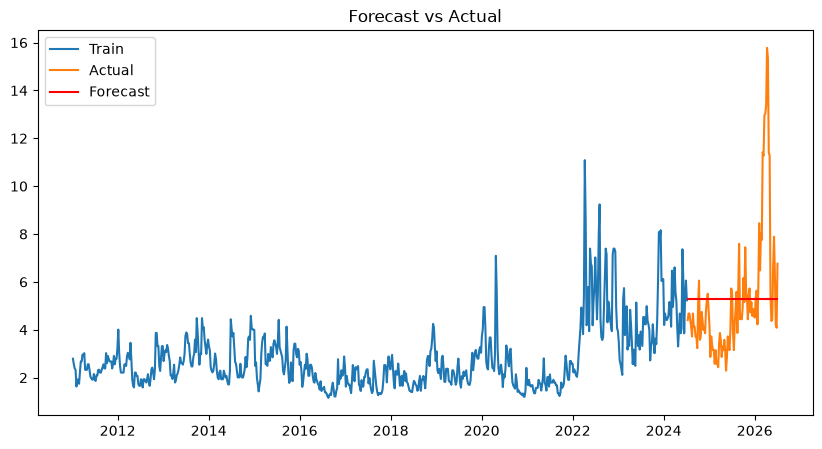

In [7]:
plt.figure(figsize=(10,5))
plt.plot(train, label="Train")
plt.plot(test, label="Actual")
plt.plot(pred, label="Forecast", color="red")
plt.legend()
plt.title("Forecast vs Actual")
plt.show()

In [8]:
#checking baselines to improve modeel

naive_value = train.iloc[-1]
naive_pred = pd.Series(naive_value, index = test.index)
print(naive_value)
print(naive_pred)


5.22975
date
2024-07-12    5.22975
2024-07-19    5.22975
2024-07-26    5.22975
2024-08-02    5.22975
2024-08-09    5.22975
               ...   
2026-06-05    5.22975
2026-06-12    5.22975
2026-06-19    5.22975
2026-06-26    5.22975
2026-07-03    5.22975
Length: 104, dtype: float64


In [9]:
from statsmodels.tsa.arima.model import ARIMA

series = tc14_rates["worldscale_rate"]

train = series.iloc[:-104]
test = series.iloc[-104:]

history = train.copy()
predictions = []

for actual in test:

    model = ARIMA(history, order=(1,1,1))
    fit = model.fit()

    forecast = fit.forecast(steps=2)
    predictions.append(forecast.iloc[0])

    # Add the actual observed value before predicting the next week
    history = pd.concat([history, pd.Series([actual])])

predictions = pd.Series(predictions, index=test.index)





c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.


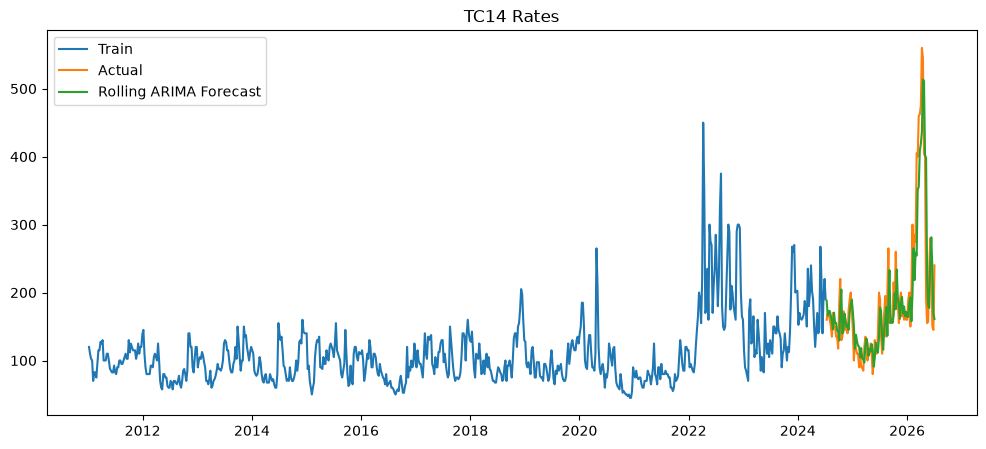

In [10]:
plt.figure(figsize=(12,5))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(predictions.index, predictions, label="Rolling ARIMA Forecast")
plt.title("TC14 Rates")
plt.legend()
plt.show()



In [11]:
print(train.min(), train.max())
print(test.min(), test.max())
print(predictions.min(), predictions.max())

pred = predictions.copy()
pred.index = test.index

results =pd.DataFrame({"actual" : test, "predicted": pred})
results.head()

mae = mean_absolute_error(results["actual"], results["predicted"])
print(mae)

rmse = np.sqrt(mean_squared_error(results["actual"], results["predicted"]))
print(rmse)

mape = (abs(results["actual"] - results["predicted"])/results["actual"]).mean()*100
print(mape)

45.0 450.0
80.0 560.0
90.9242691468898 513.6161853649778
33.7521168398135
47.35957566842472
18.041465804980085


In [12]:
#predicting into the future for TC14

series_future = tc14_rates["usd_per_bbl"]
final_model = ARIMA(series_future, order = (1,1,1))
final_fit = final_model.fit()
#get forecast and corresponding stats
future = final_fit.get_forecast(steps=12)
future_mean = future.predicted_mean
future_ci = future.conf_int()
#add dates for forecasts
future_index = pd.date_range(start=series_future.index[-1] + pd.Timedelta(weeks=1), periods = 12, freq = "W")
future_mean.index = future_index
future_ci.index = future_index

#forecast
forecast_df = pd.DataFrame({"Forecast": future_mean,
                            "Lower95": future_ci.iloc[:,0],
                            "Upper95" : future_ci.iloc[:,1]
                            })
forecast_df


c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


,Forecast,Lower95,Upper95
2026-07-12,6.865590,5.307755,8.423425
2026-07-19,6.943283,4.944979,8.941587
2026-07-26,7.001553,4.757149,9.245957
2026-08-02,7.045256,4.645451,9.445061
2026-08-09,7.078033,4.572455,9.583612
2026-08-16,7.102617,4.520649,9.684585
2026-08-23,7.121054,4.481007,9.761102
2026-08-30,7.134883,4.448609,9.821157
2026-09-06,7.145254,4.420665,9.869842
2026-09-13,7.153032,4.395550,9.910515


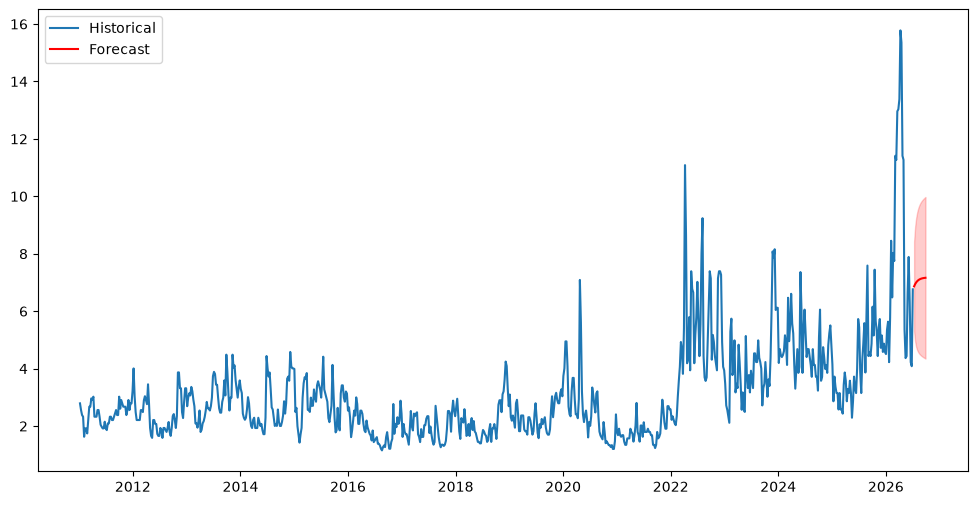

In [13]:
#visualizing results
plt.figure(figsize = (12,6))
plt.plot(series_future, label = "Historical")
plt.plot(future_mean, color = "red", label = "Forecast")
plt.fill_between(future_ci.index, future_ci.iloc[:,0], future_ci.iloc[:,1], color = "red", alpha = .2)
plt.legend()
plt.show()

In [14]:
#SARIMAX for tc14
from statsmodels.tsa.statespace.sarimax import SARIMAX
brent_df = pd.read_csv("brent_crude_oil_price_1_month_future.csv")
brent_df.head()
brent_df.columns
#align dates with TC14 rates
brent_df["date"] = pd.to_datetime(brent_df["date"], format="%d/%m/%y")
brent_df = brent_df.set_index("date")
brent_tc14 = brent_df.loc[tc14_rates.index.min():]


#making model
brent_df =  brent_df.rename(columns = {"usd_per_bbl" : "Brent"})
sarimax_tc14_df = tc14_rates.join(brent_df, how = "inner")
sarimax_tc14_df["Brent_change"] = sarimax_tc14_df["Brent"].diff()

sarimax_tc14_df["Brent_change_lag6"] = (
    sarimax_tc14_df["Brent_change"].shift(6)
)

lag6_change_df = sarimax_tc14_df.dropna(
    subset=["Brent_change_lag6"]
)
y = lag6_change_df["usd_per_bbl"]
X = lag6_change_df[["Brent_change_lag6"]]

#train test split
train_y = y.iloc[:-104]
test_y = y.iloc[-104:]
train_X = X.iloc[:-104]
test_X = X.iloc[-104:]

history_y = train_y.copy()
history_X = train_X.copy()

sarimax_tc14_predictions = []

for i, actual in enumerate(test_y):
    model = SARIMAX(history_y, exog = history_X, order= (1,1,1))
    fit = model.fit(disp=False)
    forecast = fit.forecast(steps=1, exog=test_X.iloc[[i]])

    sarimax_tc14_predictions.append(forecast.iloc[0])

    history_y = pd.concat([history_y, pd.Series([actual], index = [test_y.index[i]])])
    history_X = pd.concat([history_X, test_X.iloc[[i]]])

tc14_sarimax_preds_final = pd.Series(sarimax_tc14_predictions, index = test_y.index)

arima_rmse = np.sqrt(
    mean_squared_error(test_y, predictions)
)

sarimax_rmse = np.sqrt(
    mean_squared_error(test_y, tc14_sarimax_preds_final)
)

print("ARIMA RMSE:", arima_rmse)
print("SARIMAX RMSE:", sarimax_rmse)



c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HDw

ARIMA RMSE: 196.66347939264412
SARIMAX RMSE: 1.3358861292933415


c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


<Figure size 1000x500 with 0 Axes>

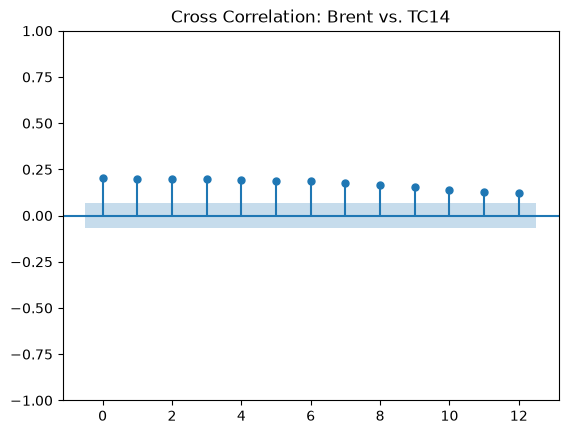

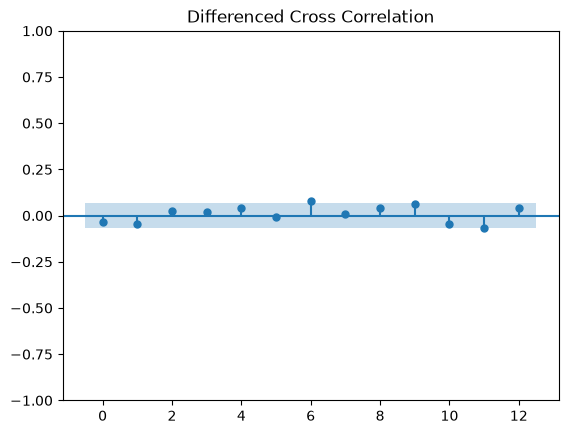

In [15]:
from statsmodels.graphics.tsaplots import plot_ccf
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plot_ccf(sarimax_tc14_df["Brent"], sarimax_tc14_df["usd_per_bbl"], lags = 12)
plt.title("Cross Correlation: Brent vs. TC14")
plt.show()

#differenced plot 
df_ccf = sarimax_tc14_df.copy()
df_ccf["TC14_diff"] = df_ccf["usd_per_bbl"].diff()
df_ccf["Brent_diff"] = df_ccf["Brent"].diff()
df_ccf = df_ccf.dropna()

plot_ccf(df_ccf["Brent_diff"], df_ccf["TC14_diff"], lags = 12)
plt.title("Differenced Cross Correlation")
plt.show()

In [16]:
#TC14 with vessel supply as the external variable
idle_mr_df = pd.read_csv("mr_40_55k_dwt_idle_fleet_weekly.csv")
idle_mr_df.head()
idle_mr_df.describe()
idle_mr_df.columns

idle_mr_df["date"] = pd.to_datetime(idle_mr_df["date"], format = "%d/%m/%y")
idle_mr_df = idle_mr_df.set_index("date")

#join dataframes, align dates
sarimax_idle_df = tc14_rates.join(idle_mr_df, how = "inner")



<Figure size 1000x500 with 0 Axes>

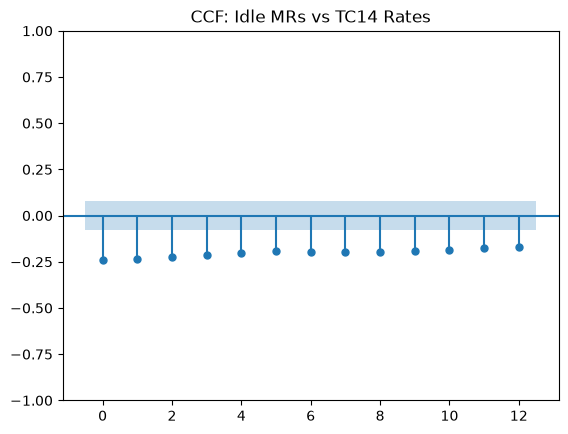

<Figure size 1000x500 with 0 Axes>

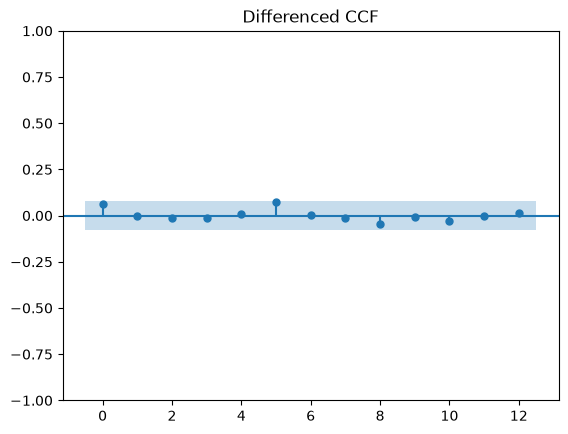

In [17]:
#CCF for idle MRs
plt.figure(figsize = (10,5))
plot_ccf(sarimax_idle_df["pct_idle_by_number"], sarimax_idle_df["usd_per_bbl"], lags = 12)
plt.title("CCF: Idle MRs vs TC14 Rates")
plt.show()

#differenced CCF
ccf_idle_df = sarimax_idle_df.copy()
ccf_idle_df["idle_diff"] = ccf_idle_df["pct_idle_by_number"].diff()
ccf_idle_df["tc14_diff"] = ccf_idle_df["usd_per_bbl"].diff()
ccf_idle_df = ccf_idle_df.dropna()

plt.figure(figsize = (10,5))
plot_ccf(ccf_idle_df["idle_diff"], ccf_idle_df["tc14_diff"], lags = 12)
plt.title("Differenced CCF")
plt.show()

In [18]:
#SARIMAX model with undifferenced idle levels
sarimax_idle_df["idle_pct_diff"] = sarimax_idle_df["pct_idle_by_number"].diff()
sarimax_idle_df["idle_pct_diff_lag5"] = sarimax_idle_df["idle_pct_diff"].shift(5)

lag5_df = sarimax_idle_df.dropna(subset =["idle_pct_diff_lag5"])

y = lag5_df["usd_per_bbl"]
X = lag5_df["pct_idle_by_number"]

#train test split
train_y = y.iloc[:-104]
test_y = y.iloc[-104:]
train_X = X.iloc[:-104]
test_X = X.iloc[-104:]

history_y = train_y.copy()
history_X = train_X.copy()

sarimax_tc14_predictions = []

for i, actual in enumerate(test_y):
    model = SARIMAX(history_y, exog = history_X, order= (1,1,1))
    fit = model.fit(disp=False)
    forecast = fit.forecast(steps=1, exog=test_X.iloc[[i]])

    sarimax_tc14_predictions.append(forecast.iloc[0])

    history_y = pd.concat([history_y, pd.Series([actual], index = [test_y.index[i]])])
    history_X = pd.concat([history_X, test_X.iloc[[i]]])

tc14_sarimax_preds_final = pd.Series(sarimax_tc14_predictions, index = test_y.index)

arima_rmse = np.sqrt(
    mean_squared_error(test_y, predictions)
)

sarimax_rmse = np.sqrt(
    mean_squared_error(test_y, tc14_sarimax_preds_final)
)

print("ARIMA RMSE:", arima_rmse)
print("SARIMAX RMSE:", sarimax_rmse)

c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HDw

ARIMA RMSE: 196.66347939264412
SARIMAX RMSE: 1.3453999830463619


c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


In [19]:
#testing TC14 against TC2
mr_rates = pd.read_csv("houston_rio_augusta_newyork_clean_ws_rates.csv")
mr_rates.head()
mr_rates.describe()
mr_rates.columns

mr_rates["date"] = pd.to_datetime(mr_rates["date"], format = "%d/%m/%y")
mr_rates = mr_rates.set_index("date")

#join dataframes and align dates
mr_comp_rates = tc14_rates.join(mr_rates, how = "inner")
print(mr_comp_rates.columns)



Index(['worldscale_rate', 'usd_per_bbl', 'houston_rio_clean_38k_ws',
       'augusta_newyork_clean_37k_ws'],
      dtype='str')


<Figure size 1000x500 with 0 Axes>

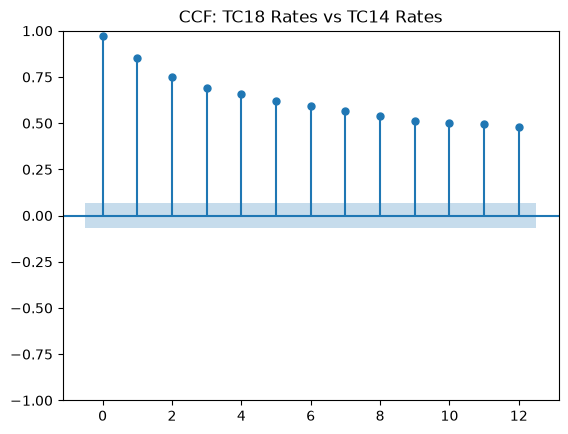

<Figure size 1000x500 with 0 Axes>

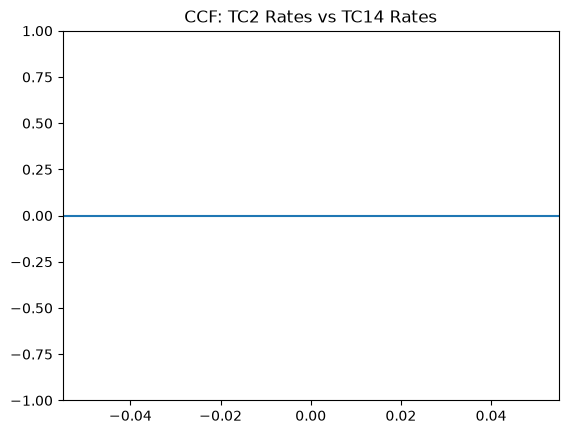

In [20]:
#CCFs for TC2 and TC18 
plt.figure(figsize = (10,5))
plot_ccf(mr_comp_rates["houston_rio_clean_38k_ws"], mr_comp_rates["worldscale_rate"], lags = 12)
plt.title("CCF: TC18 Rates vs TC14 Rates")
plt.show()

plt.figure(figsize = (10,5))
plot_ccf(mr_comp_rates["augusta_newyork_clean_37k_ws"], mr_comp_rates["worldscale_rate"], lags = 12)
plt.title("CCF: TC2 Rates vs TC14 Rates")
plt.show()

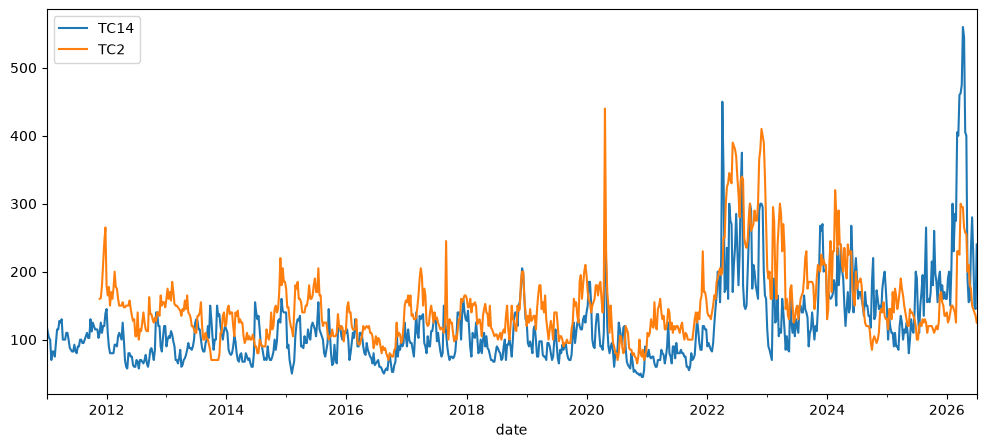

In [21]:
fig, ax = plt.subplots(figsize=(12,5))

mr_comp_rates["worldscale_rate"].plot(ax=ax, label="TC14")
mr_comp_rates["augusta_newyork_clean_37k_ws"].plot(ax=ax, label="TC2")

plt.legend()
plt.show()

<Figure size 1000x500 with 0 Axes>

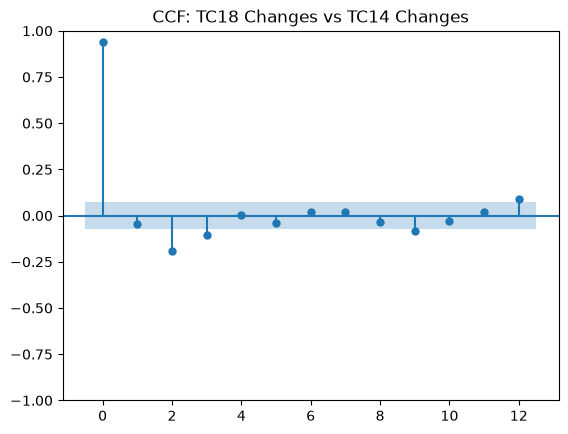

In [22]:
ccf_df = mr_comp_rates.copy()

ccf_df["tc14_diff"] = ccf_df["worldscale_rate"].diff()
ccf_df["tc18_diff"] = ccf_df["houston_rio_clean_38k_ws"].diff()

ccf_df = ccf_df.dropna()

plt.figure(figsize=(10,5))
plot_ccf(
    ccf_df["tc18_diff"],
    ccf_df["tc14_diff"],
    lags=12
)
plt.title("CCF: TC18 Changes vs TC14 Changes")
plt.show()

In [23]:
#testing lagged tc18 with sarimax

mr_comp_rates["TC18_lag1"] = (
    mr_comp_rates["houston_rio_clean_38k_ws"].shift(1)
)

lag1_df = mr_comp_rates.dropna(subset=["TC18_lag1"])

y = lag1_df["worldscale_rate"]
X = lag1_df[["TC18_lag1"]]

#train test split
train_y = y.iloc[:-104]
test_y = y.iloc[-104:]
train_X = X.iloc[:-104]
test_X = X.iloc[-104:]

history_y = train_y.copy()
history_X = train_X.copy()

sarimax_tc14_predictions = []

for i, actual in enumerate(test_y):
    model = SARIMAX(history_y, exog = history_X, order= (1,1,1))
    fit = model.fit(disp=False)
    forecast = fit.forecast(steps=1, exog=test_X.iloc[[i]])

    sarimax_tc14_predictions.append(forecast.iloc[0])

    history_y = pd.concat([history_y, pd.Series([actual], index = [test_y.index[i]])])
    history_X = pd.concat([history_X, test_X.iloc[[i]]])

tc14_sarimax_preds_final = pd.Series(sarimax_tc14_predictions, index = test_y.index)

arima_rmse = np.sqrt(
    mean_squared_error(test_y, predictions)
)

sarimax_rmse = np.sqrt(
    mean_squared_error(test_y, tc14_sarimax_preds_final)
)

print("ARIMA RMSE:", arima_rmse)
print("SARIMAX RMSE:", sarimax_rmse)

c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HDw

ARIMA RMSE: 47.35957566842472
SARIMAX RMSE: 46.97898491031496


c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


In [24]:
#contextualizing error metrics
print(tc14_rates["worldscale_rate"].describe())
mae = mean_absolute_error(test_y, tc14_sarimax_preds_final)
print(mae)

count    809.000000
mean     120.104450
std       62.577694
min       45.000000
25%       80.000000
50%      105.000000
75%      138.500000
max      560.000000
Name: worldscale_rate, dtype: float64
32.95227681720224


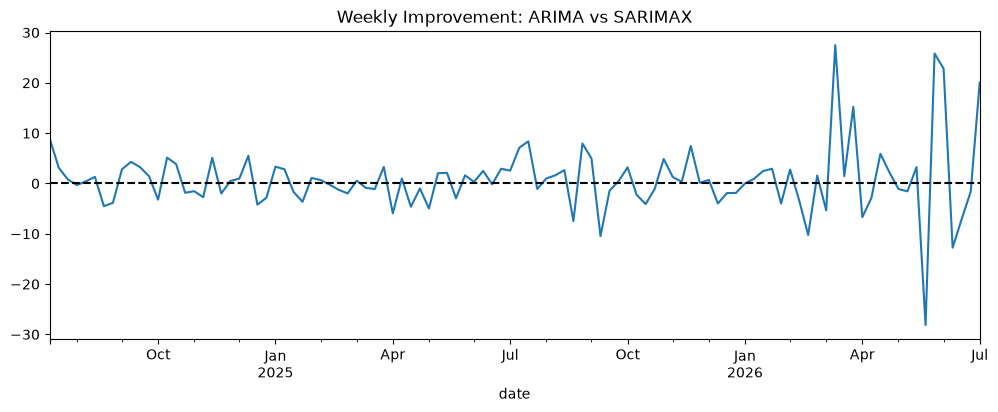

In [25]:
error_comparison = pd.DataFrame({
    "ARIMA_error": abs(test_y - predictions),
    "SARIMAX_error": abs(test_y - tc14_sarimax_preds_final)
})

error_comparison["improvement"] = (
    error_comparison["ARIMA_error"] -
    error_comparison["SARIMAX_error"]
)

error_comparison["improvement"].plot(
    figsize=(12,4),
    title="Weekly Improvement: ARIMA vs SARIMAX"
)

plt.axhline(0, color="black", linestyle="--")
plt.show()

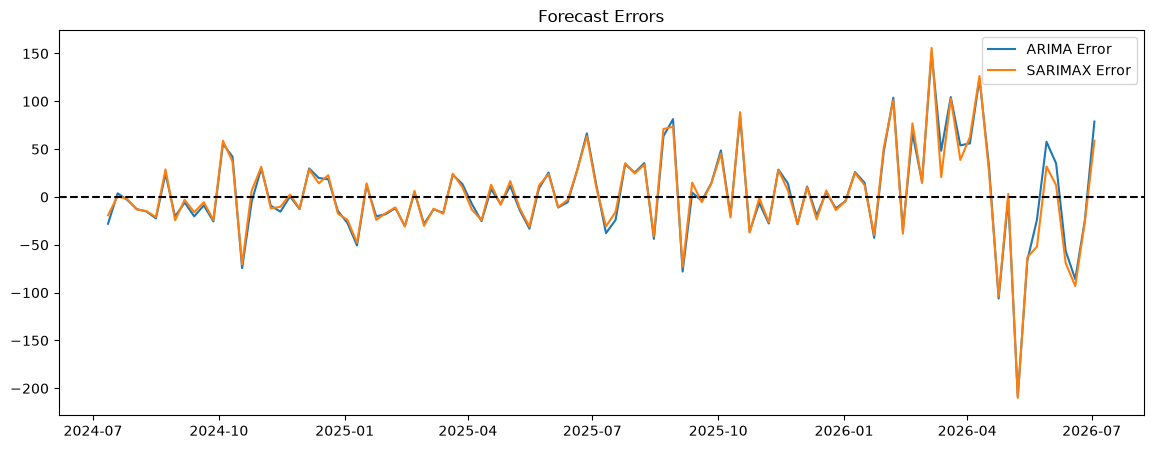

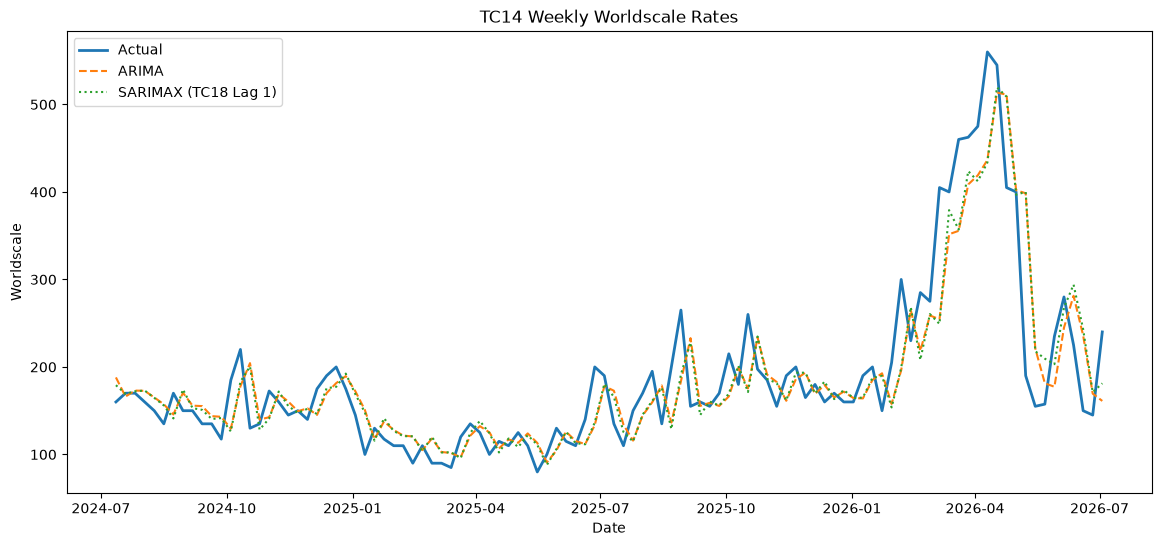

In [26]:
arima_error = test_y - predictions
sarimax_error = test_y - tc14_sarimax_preds_final

plt.figure(figsize=(14,5))

plt.plot(arima_error.index,
         arima_error,
         label="ARIMA Error")

plt.plot(sarimax_error.index,
         sarimax_error,
         label="SARIMAX Error")

plt.axhline(0,
            color="black",
            linestyle="--")

plt.legend()
plt.title("Forecast Errors")

plt.show()

#actual rates
plt.figure(figsize=(14,6))

plt.plot(test_y.index, test_y,
         label="Actual",
         linewidth=2)

plt.plot(test_y.index, predictions,
         label="ARIMA",
         linestyle="--")

plt.plot(test_y.index,
         tc14_sarimax_preds_final,
         label="SARIMAX (TC18 Lag 1)",
         linestyle=":")

plt.title("TC14 Weekly Worldscale Rates")
plt.xlabel("Date")
plt.ylabel("Worldscale")
plt.legend()

plt.show()

In [ ]:
#using SARIMAX with lagged TC18 to predict future TC14 values 
final_df = mr_comp_rates.dropna(subset = ["TC18_lag1"])
y = final_df["worldscale_rate"]
X = final_df[["TC18_lag1"]]

#fit model
final_model = SARIMAX(y, exog = X, order= (1,1,1))
final_fit = final_model.fit(disp = False)

#generating future dates for exogenous variable
future_dates = pd.date_range(start = y.index[-1] + pd.Timedelta(weeks=1), periods = 12, freq = "W-FRI")
future_X = pd.DataFrame(index = future_dates, columns = ["TC18_lag1"])
#fill in values for future TC18 rates, use ARIMA to generate
series = mr_comp_rates["houston_rio_clean_38k_ws"]
model = ARIMA(series, order=(1,1,1))
fit = model.fit()
tc18_future_forecast = fit.forecast(steps = 13)
future_X ["TC18_lag1"] = tc18_future_forecast.iloc[:12].values

#use results of ARIMA as exogeneous input for SARIMAX 
future_tc14 = final_fit.forecast(steps = 12, exog = future_X)
print(future_tc14)


c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HDw

2026-07-10    264.825991
2026-07-17    260.996188
2026-07-24    259.411063
2026-07-31    258.799725
2026-08-07    258.600602
2026-08-14    258.567975
2026-08-21    258.596189
2026-08-28    258.641254
2026-09-04    258.685991
2026-09-11    258.724619
2026-09-18    258.755997
2026-09-25    258.780709
Freq: W-FRI, Name: predicted_mean, dtype: float64


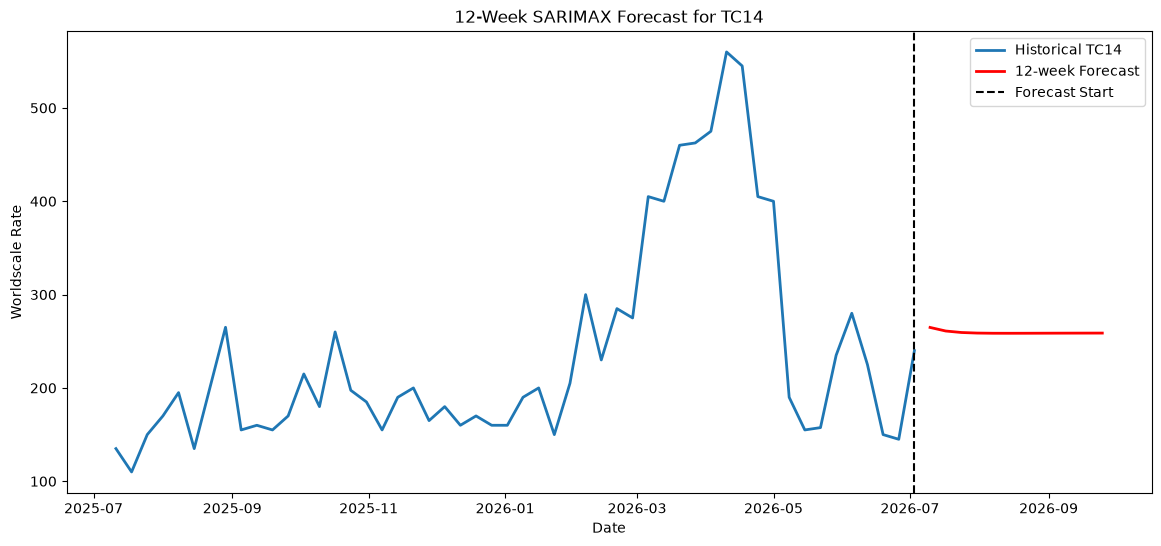

In [41]:
#plot with future rates 
plt.figure(figsize=(14,6))

# Last year of historical data
plt.plot(
    y.index[-52:],
    y.iloc[-52:],
    label="Historical TC14",
    linewidth=2
)

# Future forecast
plt.plot(
    future_tc14.index,
    future_tc14,
    color="red",
    linewidth=2,
    label="12-week Forecast"
)

plt.axvline(
    y.index[-1],
    color="black",
    linestyle="--",
    label="Forecast Start"
)

plt.title("12-Week SARIMAX Forecast for TC14")
plt.xlabel("Date")
plt.ylabel("Worldscale Rate")
plt.legend()

plt.show()

In [ ]:
#backtesting model


In [28]:
#same thing for TC5, starting with exponential smoothing

tc5_rates = pd.read_csv("ras_tanura_chiba_clean_55k_rates.csv")
tc5_rates.head()
tc5_rates.columns

Index(['date', 'worldscale_rate'], dtype='str')

2024-07-12    225.0
2024-07-19    225.0
2024-07-26    225.0
2024-08-02    225.0
2024-08-09    225.0
              ...  
2026-06-05    225.0
2026-06-12    225.0
2026-06-19    225.0
2026-06-26    225.0
2026-07-03    225.0
Freq: W-FRI, Length: 104, dtype: float64


c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


<Axes: xlabel='date'>

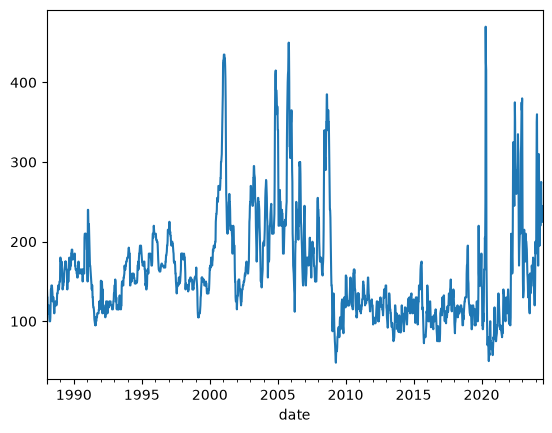

In [29]:
#exponential smoothing model
# index is already date, just ensure it's datetime
tc5_rates["date"] = pd.to_datetime(
    tc5_rates["date"],
    format="%d/%m/%y"
)

tc5_rates = tc5_rates.sort_values("date")
tc5_rates = tc5_rates.set_index("date")

series = tc5_rates["worldscale_rate"]

train_tc5 = series[:-104]
test_tc5 = series[-104:]

tc5_model = ExponentialSmoothing(train_tc5, trend = None, seasonal = None, seasonal_periods = 52)



fit_tc5= tc5_model.fit()
pred_tc5 = fit_tc5.forecast(len(test_tc5))
print(pred_tc5)

train_tc5.plot()

In [30]:
#evaluate exponential smoothing performance 
print(train_tc5.min(), train_tc5.max())
print(test_tc5.min(), test_tc5.max())
print(pred_tc5.min(), pred_tc5.max())

pred = pred_tc5.copy()
pred.index = test_tc5.index

results =pd.DataFrame({"actual" : test_tc5, "predicted": pred})
results.head()

mae = mean_absolute_error(results["actual"], results["predicted"])
print(mae)

rmse = np.sqrt(mean_squared_error(results["actual"], results["predicted"]))
print(rmse)

mape = (abs(results["actual"] - results["predicted"])/results["actual"]).mean()*100
print(mape)

48.0 470.0
105.0 700.0
225.0000000745058 225.0000000745058
128.1971154333307
182.14451019851066
55.922912176672256


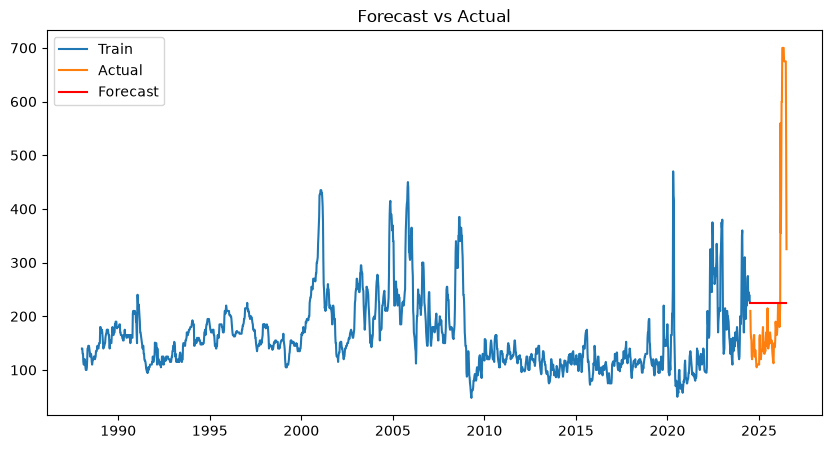

In [31]:
#visualize results of model 
plt.figure(figsize=(10,5))
plt.plot(train_tc5, label="Train")
plt.plot(test_tc5, label="Actual")
plt.plot(pred, label="Forecast", color="red")
plt.legend()
plt.title("Forecast vs Actual")
plt.show()

In [32]:
#now make rolling ARIMA model to get better accuracy 

tc5_series = tc5_rates["worldscale_rate"]

arima_train_tc5 = tc5_series.iloc[:-104]
arima_test_tc5 = tc5_series.iloc[-104:]

history = train.copy()
predictions_tc5 = []

for actual in arima_test_tc5:

    model = ARIMA(history, order=(1,1,1))
    fit = model.fit()

    forecast = fit.forecast(steps=2)
    predictions_tc5.append(forecast.iloc[0])

    # Add the actual observed value before predicting the next week
    history = pd.concat([history, pd.Series([actual])])

predictions_tc5 = pd.Series(predictions_tc5, index=test.index)

c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.


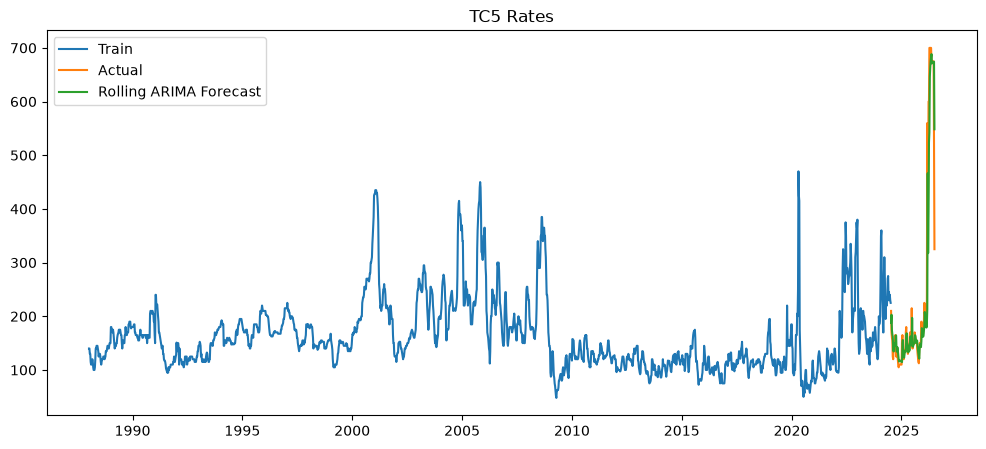

In [33]:
#graph to see results 
plt.figure(figsize=(12,5))

plt.plot(arima_train_tc5.index, arima_train_tc5, label="Train")
plt.plot(arima_test_tc5.index, arima_test_tc5, label="Actual")
plt.plot(predictions_tc5.index, predictions_tc5, label="Rolling ARIMA Forecast")
plt.title("TC5 Rates")
plt.legend()
plt.show()


In [34]:
#error metrics 
print(arima_train_tc5.min(), arima_train_tc5.max())
print(arima_test_tc5.min(), arima_test_tc5.max())
print(predictions_tc5.min(), predictions_tc5.max())

pred = predictions_tc5.copy()
pred.index = arima_test_tc5.index

results =pd.DataFrame({"actual" : arima_test_tc5, "predicted": pred})
results.head()

mae = mean_absolute_error(results["actual"], results["predicted"])
print(mae)

rmse = np.sqrt(mean_squared_error(results["actual"], results["predicted"]))
print(rmse)

mape = (abs(results["actual"] - results["predicted"])/results["actual"]).mean()*100
print(mape)

48.0 470.0
105.0 700.0
114.68480097582432 688.4070904578102
25.83569011642711
56.433599649959774
10.084937109902564


In [35]:
#future predictions for the next 12 weeks
series_future_tc5 = tc5_rates["worldscale_rate"]
final_model_tc5 = ARIMA(series_future_tc5, order = (1,1,1))
final_fit_tc5 = final_model_tc5.fit()
#get forecast and corresponding stats
future_tc5 = final_fit_tc5.get_forecast(steps=12)
future_mean_tc5 = future_tc5.predicted_mean
future_ci_tc5 = future_tc5.conf_int()
#add dates for forecasts
future_index_tc5 = pd.date_range(start=series_future_tc5.index[-1] + pd.Timedelta(weeks=1), periods = 12, freq = "W")
future_mean_tc5.index = future_index_tc5
future_ci_tc5.index = future_index_tc5

#forecast
forecast_df_tc5 = pd.DataFrame({"Forecast": future_mean_tc5,
                            "Lower95": future_ci_tc5.iloc[:,0],
                            "Upper95" : future_ci_tc5.iloc[:,1]
                            })
forecast_df_tc5

c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HDwyer\CodingProjects\Freight-Forecasting-Model\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


,Forecast,Lower95,Upper95
2026-07-12,295.375206,256.974981,333.775432
2026-07-19,284.867905,226.958871,342.776939
2026-07-26,281.141183,207.741691,354.540675
2026-08-02,279.819392,193.343836,366.294948
2026-08-09,279.350580,181.428233,377.272927
2026-08-16,279.184302,170.986576,387.382029
2026-08-23,279.125327,161.535932,396.714722
2026-08-30,279.104410,152.816284,405.392535
2026-09-06,279.096991,144.670665,413.523317
2026-09-13,279.094359,136.994754,421.193964


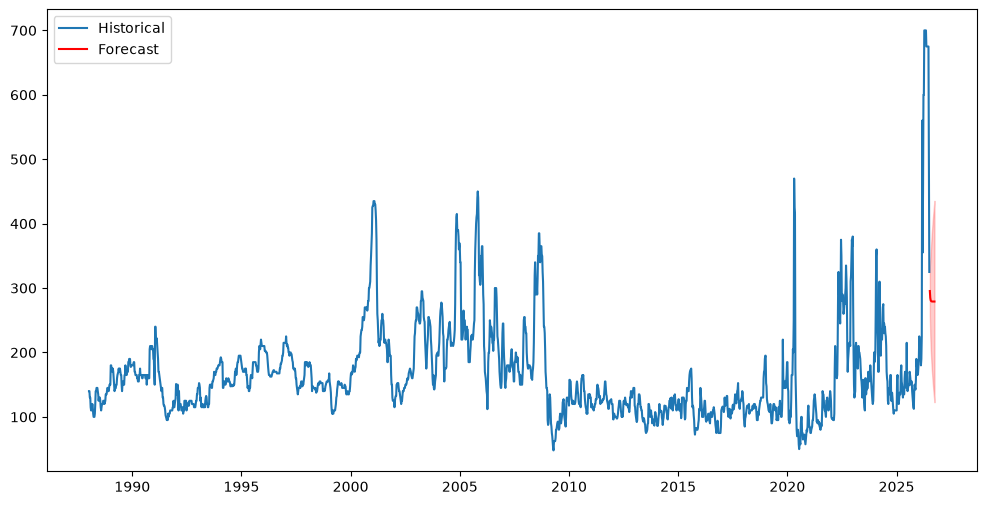

In [36]:
#visualize results
plt.figure(figsize = (12,6))
plt.plot(series_future_tc5, label = "Historical")
plt.plot(future_mean_tc5, color = "red", label = "Forecast")
plt.fill_between(future_ci_tc5.index, future_ci_tc5.iloc[:,0], future_ci_tc5.iloc[:,1], color = "red", alpha = .2)
plt.legend()
plt.show()


In [37]:
#TC5 sarimax 
